<a href="https://colab.research.google.com/github/pearlin-in/simCLR-STL10-PyTorch/blob/main/self_supervised_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os, time, torch, torchvision
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T
from torchvision.models import resnet18
import pandas as pd
import numpy as np

drive.mount('/content/drive', force_remount=False)
CHECKPOINT_DIR = '/content/drive/MyDrive/ssl-cv-project'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
encoder_path = os.path.join(CHECKPOINT_DIR, 'simclr_latest.pth')
assert os.path.exists(encoder_path), f"Missing checkpoint at {encoder_path}!"
print("Ready. Checkpoint located.")

Mounted at /content/drive
Ready. Checkpoint located.


In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available(), torch.cuda.get_device_name(0))

2.11.0+cu128
True Tesla T4


In [ ]:
import torchvision

# Labeled train split (for Phase 1 baseline)
train_labeled = torchvision.datasets.STL10(
    root='./data', split='train', download=True
)

# Unlabeled split (for SSL pretraining, Phase 2-3)
unlabeled = torchvision.datasets.STL10(
    root='./data', split='unlabeled', download=True
)

# Test split (for evaluation)
test = torchvision.datasets.STL10(
    root='./data', split='test'
)

print(len(train_labeled), len(unlabeled), len(test))

100%|██████████| 2.64G/2.64G [01:25<00:00, 31.0MB/s]


5000 100000 8000


In [2]:
import torchvision
import torchvision.transforms as T

train_transform = T.Compose([
    T.RandomCrop(96, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.4467, 0.4398, 0.4066], std=[0.2603, 0.2566, 0.2713]),  # STL-10 stats
])

test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.4467, 0.4398, 0.4066], std=[0.2603, 0.2566, 0.2713]),
])

train_full = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=train_transform)
test_set   = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=test_transform)

100%|██████████| 2.64G/2.64G [12:19<00:00, 3.57MB/s]


In [3]:
import numpy as np
from torch.utils.data import Subset

def stratified_subset(dataset, fraction, seed=0):
    labels = np.array(dataset.labels)
    rng = np.random.default_rng(seed)
    indices = []
    for c in np.unique(labels):
        class_idx = np.where(labels == c)[0]
        n_keep = max(1, int(len(class_idx) * fraction))
        indices.extend(rng.choice(class_idx, n_keep, replace=False))
    return Subset(dataset, indices)

train_100 = train_full
train_10  = stratified_subset(train_full, 0.10)
train_1   = stratified_subset(train_full, 0.01)

In [ ]:
import torch.nn as nn
from torchvision.models import resnet18

def make_model(num_classes=10):
    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.cuda()

In [18]:
import torch
from torch.utils.data import DataLoader

def train_and_eval(train_dataset, epochs=30, batch_size=128, lr=1e-3, tag=""):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader  = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)

    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.cuda(), labels.cuda()
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()

        if (epoch + 1) % 5 == 0:
            acc = evaluate(model, test_loader)
            print(f"[{tag}] epoch {epoch+1}/{epochs} — test acc: {acc:.2%}")

    return evaluate(model, test_loader)

In [4]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.cuda(), labels.cuda()
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

In [ ]:
acc_100 = train_and_eval(train_100, epochs=30, tag="100%")
acc_10  = train_and_eval(train_10,  epochs=50, tag="10%")   # more epochs — less data per epoch
acc_1   = train_and_eval(train_1,   epochs=100, tag="1%")   # even more — otherwise it barely trains

print(f"100%: {acc_100:.2%} | 10%: {acc_10:.2%} | 1%: {acc_1:.2%}")

[100%] epoch 5/30 — test acc: 50.34%
[100%] epoch 10/30 — test acc: 58.98%
[100%] epoch 15/30 — test acc: 63.61%
[100%] epoch 20/30 — test acc: 65.95%
[100%] epoch 25/30 — test acc: 67.10%
[100%] epoch 30/30 — test acc: 67.01%
[10%] epoch 5/50 — test acc: 28.68%
[10%] epoch 10/50 — test acc: 38.25%
[10%] epoch 15/50 — test acc: 40.44%
[10%] epoch 20/50 — test acc: 40.86%
[10%] epoch 25/50 — test acc: 42.00%
[10%] epoch 30/50 — test acc: 40.02%
[10%] epoch 35/50 — test acc: 41.48%
[10%] epoch 40/50 — test acc: 40.26%
[10%] epoch 45/50 — test acc: 40.74%
[10%] epoch 50/50 — test acc: 39.94%
[1%] epoch 5/100 — test acc: 14.96%
[1%] epoch 10/100 — test acc: 14.77%
[1%] epoch 15/100 — test acc: 10.96%
[1%] epoch 20/100 — test acc: 12.03%
[1%] epoch 25/100 — test acc: 15.72%
[1%] epoch 30/100 — test acc: 21.32%
[1%] epoch 35/100 — test acc: 21.96%
[1%] epoch 40/100 — test acc: 22.51%
[1%] epoch 45/100 — test acc: 22.59%
[1%] epoch 50/100 — test acc: 23.74%
[1%] epoch 55/100 — test acc: 24.20

In [ ]:
import torchvision.transforms as T

simclr_transform = T.Compose([
    T.RandomResizedCrop(96, scale=(0.2, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0)),
    T.ToTensor(),
    T.Normalize(mean=[0.4467, 0.4398, 0.4066], std=[0.2603, 0.2566, 0.2713]),
])

In [ ]:
from torch.utils.data import Dataset

class ContrastiveSTL10(Dataset):
    def __init__(self, base_dataset, transform):
        self.base = base_dataset  # STL10 unlabeled split, transform=None
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, _ = self.base[idx]  # PIL image, ignore the dummy -1 label
        view1 = self.transform(img)
        view2 = self.transform(img)  # independent call → different random augmentation
        return view1, view2
unlabeled_raw = torchvision.datasets.STL10(root='./data', split='unlabeled', transform=None)
contrastive_dataset = ContrastiveSTL10(unlabeled_raw, simclr_transform)

from torch.utils.data import DataLoader
contrastive_loader = DataLoader(
    contrastive_dataset, batch_size=256, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True  # keeps batch size constant for NT-Xent
)

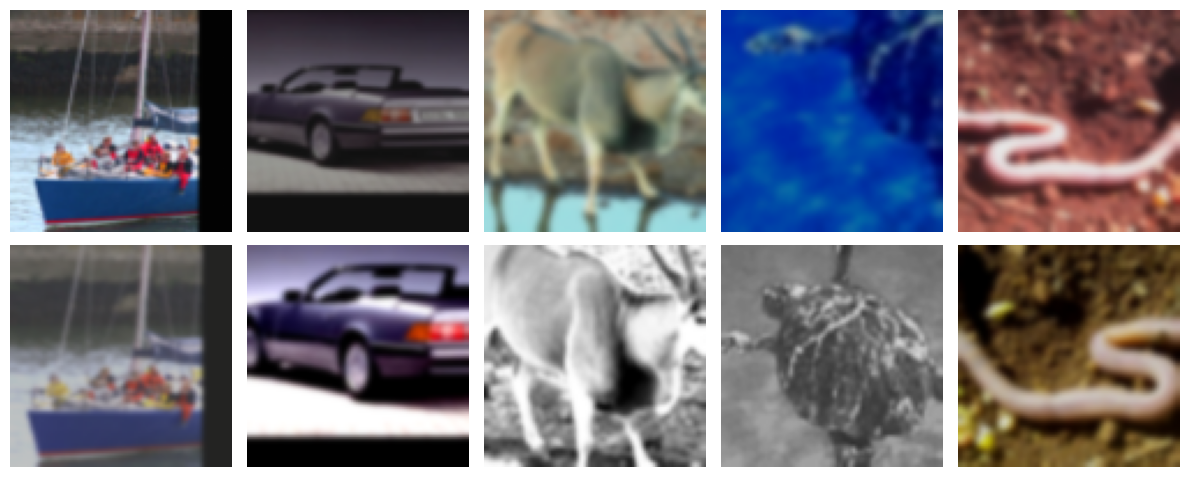

In [ ]:
import matplotlib.pyplot as plt

def denormalize(tensor):
    mean = torch.tensor([0.4467, 0.4398, 0.4066]).view(3,1,1)
    std  = torch.tensor([0.2603, 0.2566, 0.2713]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

v1_batch, v2_batch = next(iter(contrastive_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(denormalize(v1_batch[i]).permute(1, 2, 0))
    axes[0, i].axis('off')
    axes[1, i].imshow(denormalize(v2_batch[i]).permute(1, 2, 0))
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('View 1')
axes[1, 0].set_ylabel('View 2')
plt.tight_layout()
plt.show()

In [20]:
import torch.nn as nn
from torchvision.models import resnet18

class SimCLRModel(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()
        base = resnet18(weights=None)
        feat_dim = base.fc.in_features       # 512 for resnet18
        base.fc = nn.Identity()               # strip classification head
        self.encoder = base

        self.projection_head = nn.Sequential(
            nn.Linear(feat_dim, feat_dim),
            nn.ReLU(),
            nn.Linear(feat_dim, projection_dim),
        )

    def forward(self, x):
        h = self.encoder(x)          # this is what you KEEP after pretraining
        z = self.projection_head(h)  # this is what the loss actually operates on
        return h, z

In [ ]:
import torch
import torch.nn.functional as F

def nt_xent_loss(z1, z2, temperature=0.5):
    N = z1.size(0)
    z = torch.cat([z1, z2], dim=0)              # (2N, D)
    z = F.normalize(z, dim=1)

    sim = torch.matmul(z, z.T) / temperature     # (2N, 2N) cosine similarity matrix

    # mask out self-similarity (i vs i) so a view is never its own "negative" comparison
    mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, float('-inf'))

    # positive index for row i: i+N if i<N else i-N
    targets = torch.cat([torch.arange(N, 2 * N), torch.arange(0, N)]).to(z.device)

    loss = F.cross_entropy(sim, targets)
    return loss

In [ ]:
import torch
import torch.nn.functional as F

def verify_nt_xent():
    # 3 images -> 6 views total, 4-dim features
    torch.manual_seed(42)
    z1 = torch.randn(3, 4)
    z2 = torch.randn(3, 4)

    # --- Vectorized version ---
    N = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    z = F.normalize(z, dim=1)

    sim = torch.matmul(z, z.T) / 0.5
    mask = torch.eye(2 * N, dtype=torch.bool)
    sim.masked_fill_(mask, float('-inf'))

    targets = torch.cat([torch.arange(N, 2 * N), torch.arange(0, N)])
    vectorized_loss = F.cross_entropy(sim, targets).item()

    # --- Loop version for double checking ---
    loop_loss = 0.0
    tau = 0.5

    z_norm = F.normalize(torch.cat([z1, z2], dim=0), dim=1)

    for i in range(2 * N):
        # view i's matching pair index
        pos_idx = (i + N) if i < N else (i - N)

        # exp(sim(i, pos) / tau)
        pos_sim = torch.dot(z_norm[i], z_norm[pos_idx]) / tau
        num = torch.exp(pos_sim)

        # sum of all negatives (k != i)
        den = 0.0
        for k in range(2 * N):
            if k != i:
                sim_ik = torch.dot(z_norm[i], z_norm[k]) / tau
                den += torch.exp(sim_ik)

        loop_loss += -torch.log(num / den)

    loop_loss /= (2 * N)

    print(f"Vectorized NT-Xent Loss: {vectorized_loss:.6f}")
    print(f"Reference Loop Loss:    {loop_loss.item():.6f}")

    assert abs(vectorized_loss - loop_loss.item()) < 1e-5, "Mismatch found!"
    print("\nSUCCESS: Vectorized loss matches reference implementation perfectly!")

verify_nt_xent()

Vectorized NT-Xent Loss: 1.989764
Reference Loop Loss:    1.989764

SUCCESS: Vectorized loss matches reference implementation perfectly!


In [ ]:
import torch, os, time

model = SimCLRModel().cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scaler = torch.cuda.amp.GradScaler()

epochs = 20
start_epoch = 0
ckpt_path = os.path.join(CHECKPOINT_DIR, 'simclr_latest.pth')

# ---- Resume if a checkpoint exists ----
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    print(f"Resumed from epoch {start_epoch}")

for epoch in range(start_epoch, epochs):
    model.train()
    total_loss = 0
    t0 = time.time()

    for view1, view2 in contrastive_loader:
        view1, view2 = view1.cuda(non_blocking=True), view2.cuda(non_blocking=True)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():  # mixed precision forward pass
            _, z1 = model(view1)
            _, z2 = model(view2)
            loss = nt_xent_loss(z1, z2, temperature=0.5)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(contrastive_loader)
    print(f"epoch {epoch+1}/{epochs} — avg NT-Xent loss: {avg_loss:.4f} — {time.time()-t0:.0f}s")

    # ---- Save every epoch, not just every 5 ----
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
    }, ckpt_path)

/tmp/ipykernel_802/3965742096.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_802/3965742096.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # mixed precision forward pass


epoch 1/20 — avg NT-Xent loss: 5.1145 — 704s
epoch 2/20 — avg NT-Xent loss: 4.9085 — 715s
epoch 3/20 — avg NT-Xent loss: 4.8484 — 717s
epoch 4/20 — avg NT-Xent loss: 4.8069 — 712s
epoch 5/20 — avg NT-Xent loss: 4.7807 — 693s
epoch 6/20 — avg NT-Xent loss: 4.7628 — 703s
epoch 7/20 — avg NT-Xent loss: 4.7456 — 687s
epoch 8/20 — avg NT-Xent loss: 4.7329 — 688s
epoch 9/20 — avg NT-Xent loss: 4.7236 — 692s
epoch 10/20 — avg NT-Xent loss: 4.7135 — 683s
epoch 11/20 — avg NT-Xent loss: 4.7064 — 690s
epoch 12/20 — avg NT-Xent loss: 4.6996 — 698s
epoch 13/20 — avg NT-Xent loss: 4.6914 — 694s
epoch 14/20 — avg NT-Xent loss: 4.6849 — 699s
epoch 15/20 — avg NT-Xent loss: 4.6807 — 677s
epoch 16/20 — avg NT-Xent loss: 4.6762 — 683s
epoch 17/20 — avg NT-Xent loss: 4.6696 — 676s
epoch 18/20 — avg NT-Xent loss: 4.6647 — 697s
epoch 19/20 — avg NT-Xent loss: 4.6615 — 691s
epoch 20/20 — avg NT-Xent loss: 4.6570 — 719s


In [9]:
from torchvision.models import resnet18
import torch.nn as nn

def make_linear_probe_model(encoder_path):
    encoder = resnet18(weights=None)
    feat_dim = encoder.fc.in_features
    encoder.fc = nn.Identity()

    ckpt = torch.load(encoder_path, map_location='cuda')
    state_dict = ckpt['model_state_dict'] if (isinstance(ckpt, dict) and 'model_state_dict' in ckpt) else ckpt

    clean_state = {}
    for k, v in state_dict.items():
        if k.startswith('encoder.'):
            clean_state[k.replace('encoder.', '')] = v
        elif not k.startswith('projector.'):
            clean_state[k] = v

    encoder.load_state_dict(clean_state, strict=False)
    for param in encoder.parameters():
        param.requires_grad = False
    encoder.eval()

    class ProbeModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.encoder = encoder
            self.linear = nn.Linear(feat_dim, 10)
        def forward(self, x):
            with torch.no_grad():
                h = self.encoder(x)
            return self.linear(h)
    return ProbeModel().cuda()

print("RAM updated: make_linear_probe_model fixed!")

RAM updated: make_linear_probe_model fixed!


In [12]:
import torch, os, time
import torch.nn as nn
from torch.utils.data import DataLoader

def train_and_eval_probe(train_dataset, encoder_path, epochs, batch_size=128, lr=1e-3, tag=""):
    # Guard against batch_size larger than tiny subsets (like 1% = 500 samples)
    eff_bs = min(batch_size, max(4, len(train_dataset) // 4))
    train_loader = DataLoader(
        train_dataset, batch_size=eff_bs, shuffle=True,
        num_workers=2, pin_memory=True, persistent_workers=True, drop_last=False
    )
    test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

    model = make_linear_probe_model(encoder_path)
    optimizer = torch.optim.Adam(model.linear.parameters(), lr=lr)
    scaler = torch.amp.GradScaler('cuda')  # <--- MODERN AMP
    criterion = nn.CrossEntropyLoss()

    ckpt_path = os.path.join(CHECKPOINT_DIR, f'probe_{tag}.pth')
    start_epoch = 0
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location='cuda')
        model.linear.load_state_dict(ckpt['linear_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scaler.load_state_dict(ckpt['scaler_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        print(f"[{tag}] resumed from epoch {start_epoch}")

    for epoch in range(start_epoch, epochs):
        model.linear.train()
        t0 = time.time()
        for imgs, labels in train_loader:
            imgs, labels = imgs.cuda(non_blocking=True), labels.cuda(non_blocking=True)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):  # <--- MODERN AMP
                loss = criterion(model(imgs), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            acc = evaluate(model, test_loader)
            print(f"[{tag}] epoch {epoch+1}/{epochs} — test acc: {acc:.2%} — {time.time()-t0:.0f}s")

        torch.save({
            'epoch': epoch,
            'linear_state_dict': model.linear.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
        }, ckpt_path)

    return evaluate(model, test_loader)

In [16]:
import os
import pandas as pd

encoder_path = os.path.join(CHECKPOINT_DIR, 'simclr_latest.pth')

probe_acc_100 = train_and_eval_probe(train_100, encoder_path, epochs=30, tag="100")
probe_acc_10  = train_and_eval_probe(train_10,  encoder_path, epochs=50, tag="10")
probe_acc_1   = train_and_eval_probe(train_1,   encoder_path, epochs=100, tag="1")

# Safely grab the supervised baseline numbers
baseline_100 = globals().get('acc_100', "Run Phase 1")
baseline_10  = globals().get('acc_10', "Run Phase 1")
baseline_1   = globals().get('acc_1', "Run Phase 1")

results = pd.DataFrame({
    'Labels': ['100%', '10%', '1%'],
    'Supervised (scratch)': [baseline_100, baseline_10, baseline_1],  # FIXED
    'SSL + linear probe': [probe_acc_100, probe_acc_10, probe_acc_1],
})
print(results)

[100] resumed from epoch 30
[10] resumed from epoch 50
[1] resumed from epoch 100
  Labels Supervised (scratch)  SSL + linear probe
0   100%          Run Phase 1            0.677000
1    10%          Run Phase 1            0.610625
2     1%          Run Phase 1            0.434375


In [ ]:
def make_finetune_model(encoder_path):
    encoder = resnet18(weights=None)
    feat_dim = encoder.fc.in_features
    encoder.fc = nn.Identity()
    encoder.load_state_dict(torch.load(encoder_path, map_location='cuda'))
    # no freezing here — this is the key difference from Phase 4

    class FinetuneModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.encoder = encoder
            self.linear = nn.Linear(feat_dim, 10)
        def forward(self, x):
            h = self.encoder(x)   # gradients flow through here now
            return self.linear(h)

    return FinetuneModel().cuda()

In [ ]:
def train_and_eval_finetune(train_dataset, encoder_path, epochs, requested_bs=128, lr=1e-4, tag=""):
    batch_size = min(requested_bs, max(4, len(train_dataset) // 4))
    print(f"[{tag}] dataset size={len(train_dataset)}, batch_size={batch_size}")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                               num_workers=2, pin_memory=True, persistent_workers=True,
                               drop_last=False)
    test_loader  = DataLoader(test_set, batch_size=256, shuffle=False,
                               num_workers=2, pin_memory=True)

    model = make_finetune_model(encoder_path)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # whole model, not just .linear
    scaler = torch.amp.GradScaler('cuda')
    criterion = nn.CrossEntropyLoss()

    ckpt_path = os.path.join(CHECKPOINT_DIR, f'finetune_{tag}.pth')
    start_epoch = 0
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location='cuda')
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scaler.load_state_dict(ckpt['scaler_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        print(f"[{tag}] resumed from epoch {start_epoch}")

    for epoch in range(start_epoch, epochs):
        model.train()
        t0 = time.time()
        for imgs, labels in train_loader:
            imgs, labels = imgs.cuda(non_blocking=True), labels.cuda(non_blocking=True)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                loss = criterion(model(imgs), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            acc = evaluate(model, test_loader)
            print(f"[{tag}] epoch {epoch+1}/{epochs} — test acc: {acc:.2%} — {time.time()-t0:.0f}s")

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),   # whole model this time, not just .linear
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
        }, ckpt_path)

    return evaluate(model, test_loader)

In [ ]:
finetune_acc_100 = train_and_eval_finetune(train_100, encoder_path, epochs=30, tag="100")
finetune_acc_10  = train_and_eval_finetune(train_10,  encoder_path, epochs=50, tag="10")
finetune_acc_1   = train_and_eval_finetune(train_1,   encoder_path, epochs=100, tag="1")

In [ ]:
results = pd.DataFrame({
    'Labels': ['100%', '10%', '1%'],
    'Supervised (scratch)': [acc_100, acc_10, acc_1],
    'SSL + linear probe': [probe_acc_100, probe_acc_10, probe_acc_1],
    'SSL + full fine-tune': [finetune_acc_100, finetune_acc_10, finetune_acc_1],
})
print(results)